# Orange County Analysis

In [44]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import re
import src.analysis_utils as analysis_utils
import src.table_utils as table_utils
import src.visualization_utils as visualization_utils

# Display all columns
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import Data

In [45]:
# Load in policing data
original_policing = pd.read_csv("../data/processed/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [46]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/processed/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [47]:
# Load in census data
census = analysis_utils.load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = analysis_utils.census_rollup(census)

# Policing Analysis: Stop Rates, Search Rates, and Hit Rates

In [48]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = analysis_utils.add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["action_any_search"] & policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
# Hits only count as hits if they were found in a search, and the search was discretionary
policing["disc_hit"] = (
    policing["disc_search"] & # Has to be from a discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Create a copy with all people involved in stops for sensitivity analysis
policing_multi = policing.copy()

# Filter for person 1 for each stop (usually, the main person stopped, but not always)
policing = policing[policing["person_number"] == 1].copy()

policing_analysis = analysis_utils.policing_rates(policing, census_coarse)

In [49]:
# ── Pooled policing summary table (2022-2024) ──────────────────────────────

race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

# Population (fixed — same across years, just take first)
pop_pooled = (
    df[["Perceived Race", "Population"]]
    .drop_duplicates("Perceived Race")
    .set_index("Perceived Race")
    .reindex(race_order)
)

# Stops per 1,000: mean across years (no CI)
stops_pooled = (
    df.groupby("Perceived Race")["Stops per 1,000"]
    .mean()
    .reindex(race_order)
    .apply(lambda x: f"{x:.2f}")
    .rename("Stops per 1,000")
)

# Searches per 1,000: mean across years (no CI)
searches_pooled = (
    df.groupby("Perceived Race")["Searches per 1,000"]
    .mean()
    .reindex(race_order)
    .apply(lambda x: f"{x:.2f}")
    .rename("Searches per 1,000")
)

# Search rate: pool counts across years, then compute rate + SE
search_counts = (
    df.groupby("Perceived Race")[["Search Count", "Stop Count"]]
    .sum()
    .reindex(race_order)
)
search_counts["Search Rate"] = (
    search_counts["Search Count"] / search_counts["Stop Count"]
)
search_counts["Search Rate SE"] = np.sqrt(
    search_counts["Search Rate"] *
    (1 - search_counts["Search Rate"]) /
    search_counts["Stop Count"]
)
search_counts["Search Rate (%)"] = search_counts.apply(
    lambda row: (
        f"{row['Search Rate']*100:.2f} "
        f"(±{row['Search Rate SE']*100*1.96:.2f})"
    ),
    axis=1,
)

# Hit rate: pool counts across years, then compute rate + SE
hit_counts = (
    df.groupby("Perceived Race")[["Hit Count", "Search Count"]]
    .sum()
    .reindex(race_order)
)
hit_counts["Hit Rate"] = (
    hit_counts["Hit Count"] / hit_counts["Search Count"]
)
hit_counts["Hit Rate SE"] = np.sqrt(
    hit_counts["Hit Rate"] *
    (1 - hit_counts["Hit Rate"]) /
    hit_counts["Search Count"]
)
hit_counts["Hit Rate (%)"] = hit_counts.apply(
    lambda row: (
        f"{row['Hit Rate']*100:.2f} "
        f"(±{row['Hit Rate SE']*100*1.96:.2f})"
    ),
    axis=1,
)

# Combine into single display table
table_policing_pooled = pd.concat(
    [
        pop_pooled["Population"],
        stops_pooled,
        searches_pooled,
        search_counts["Search Rate (%)"],
        hit_counts["Hit Rate (%)"],
    ],
    axis=1,
)

table_policing_pooled.columns = [
    "Population",
    "Stops per 1,000",
    "Searches per 1,000",
    "Search Rate (%) [95% CI]",
    "Hit Rate (%) [95% CI]",
]

table_policing_pooled
# table_utils.export_policing_pooled_to_latex(policing_analysis)

,Population,"Stops per 1,000","Searches per 1,000",Search Rate (%) [95% CI],Hit Rate (%) [95% CI]
Perceived Race,,,,,
Black/African American,49304,171.91,15.19,8.84 (±0.35),26.39 (±1.82)
Hispanic/Latino,1086834,65.19,6.12,9.39 (±0.12),27.81 (±0.62)
White,1198655,49.36,2.87,5.81 (±0.11),36.12 (±0.93)
Asian,699124,28.17,0.71,2.51 (±0.13),31.06 (±2.36)
Other,153072,70.79,1.98,2.79 (±0.18),26.32 (±2.86)


In [50]:
# Creating tables
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

pop = (df[["Perceived Race", "Population"]]
       .drop_duplicates("Perceived Race")
       .set_index("Perceived Race")
       .reindex(race_order))

def make_pivot_no_ci(df, value_col, digits=2):
    """Plain pivot with no CI — just the formatted number."""
    tmp = df[["Perceived Race", "Year", value_col]].copy()
    tmp["cell"] = tmp[value_col].apply(lambda x: f"{x:.{digits}f}")
    wide = tmp.pivot(index="Perceived Race", columns="Year", values="cell")
    wide = wide.reindex(columns=[y for y in (2022, 2023, 2024) if y in wide.columns])
    return wide

stops_1k    = make_pivot_no_ci(df, "Stops per 1,000")
searches_1k = make_pivot_no_ci(df, "Searches per 1,000")

tab2 = df.copy()
tab2["Search Rate"] *= 100
tab2["Hit Rate"]    *= 100
tab2["Search Rate SE"] *= 100
tab2["Hit Rate SE"]    *= 100

search_rate = table_utils.make_pivot_with_ci(tab2, "Search Rate", "Search Rate SE")
hit_rate    = table_utils.make_pivot_with_ci(tab2, "Hit Rate", "Hit Rate SE")

table_policing = pd.concat(
    [pop, stops_1k, searches_1k, search_rate, hit_rate],
    axis=1,
    keys=["Population", "Stops per 1,000", "Searches per 1,000",
          "Search Rate (%)", "Hit Rate (%)"]
)

table_policing.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table_policing.columns],
    names=["", "Year"]
)

table_policing = table_policing.reindex(race_order)

# Export — pass policing_analysis, NOT table_policing
# table_utils.export_policing_by_year(policing_analysis)
table_policing

Population Stops per 1,000                  \
Year                   Population            2022    2023    2024   
Perceived Race                                                      
Black/African American      49304          176.88  158.14  180.70   
Hispanic/Latino           1086834           65.75   58.48   71.35   
White                     1198655           52.00   44.19   51.89   
Asian                      699124           28.52   26.03   29.96   
Other                      153072           69.77   61.83   80.77   

                       Searches per 1,000               Search Rate (%)  \
Year                                 2022   2023   2024            2022   
Perceived Race                                                            
Black/African American              16.33  13.49  15.76    9.23 (±0.61)   
Hispanic/Latino                      5.89   5.41   7.06    8.96 (±0.21)   
White                                3.12   2.47   3.02    6.01 (±0.19)   
Asian                                0.73   0.67   0.71    2.57 (±0.22)   
Other                                1.91   1.57   2.44    2.74 (±0.31)   

                                                     Hit Rate (%)  \
Year                            2023          2024           2022   
Perceived Race                                                      
Black/African American  8.53 (±0.62)  8.72 (±0.59)  29.19 (±3.14)   
Hispanic/Latino         9.25 (±0.23)  9.89 (±0.21)  30.72 (±1.13)   
White                   5.58 (±0.20)  5.81 (±0.18)  37.06 (±1.55)   
Asian                   2.59 (±0.23)  2.37 (±0.21)  31.97 (±4.04)   
Other                   2.55 (±0.32)  3.02 (±0.30)  29.01 (±5.20)   

                                                      
Year                             2023           2024  
Perceived Race                                        
Black/African American  25.11 (±3.30)  24.58 (±3.03)  
Hispanic/Latino         27.52 (±1.14)  25.60 (±0.98)  
White                   37.62 (±1.75)  33.91 (±1.54)  
Asian                   30.36 (±4.15)  30.78 (±4.06)  
Other                   23.65 (±5.37)  25.94 (±4.44)

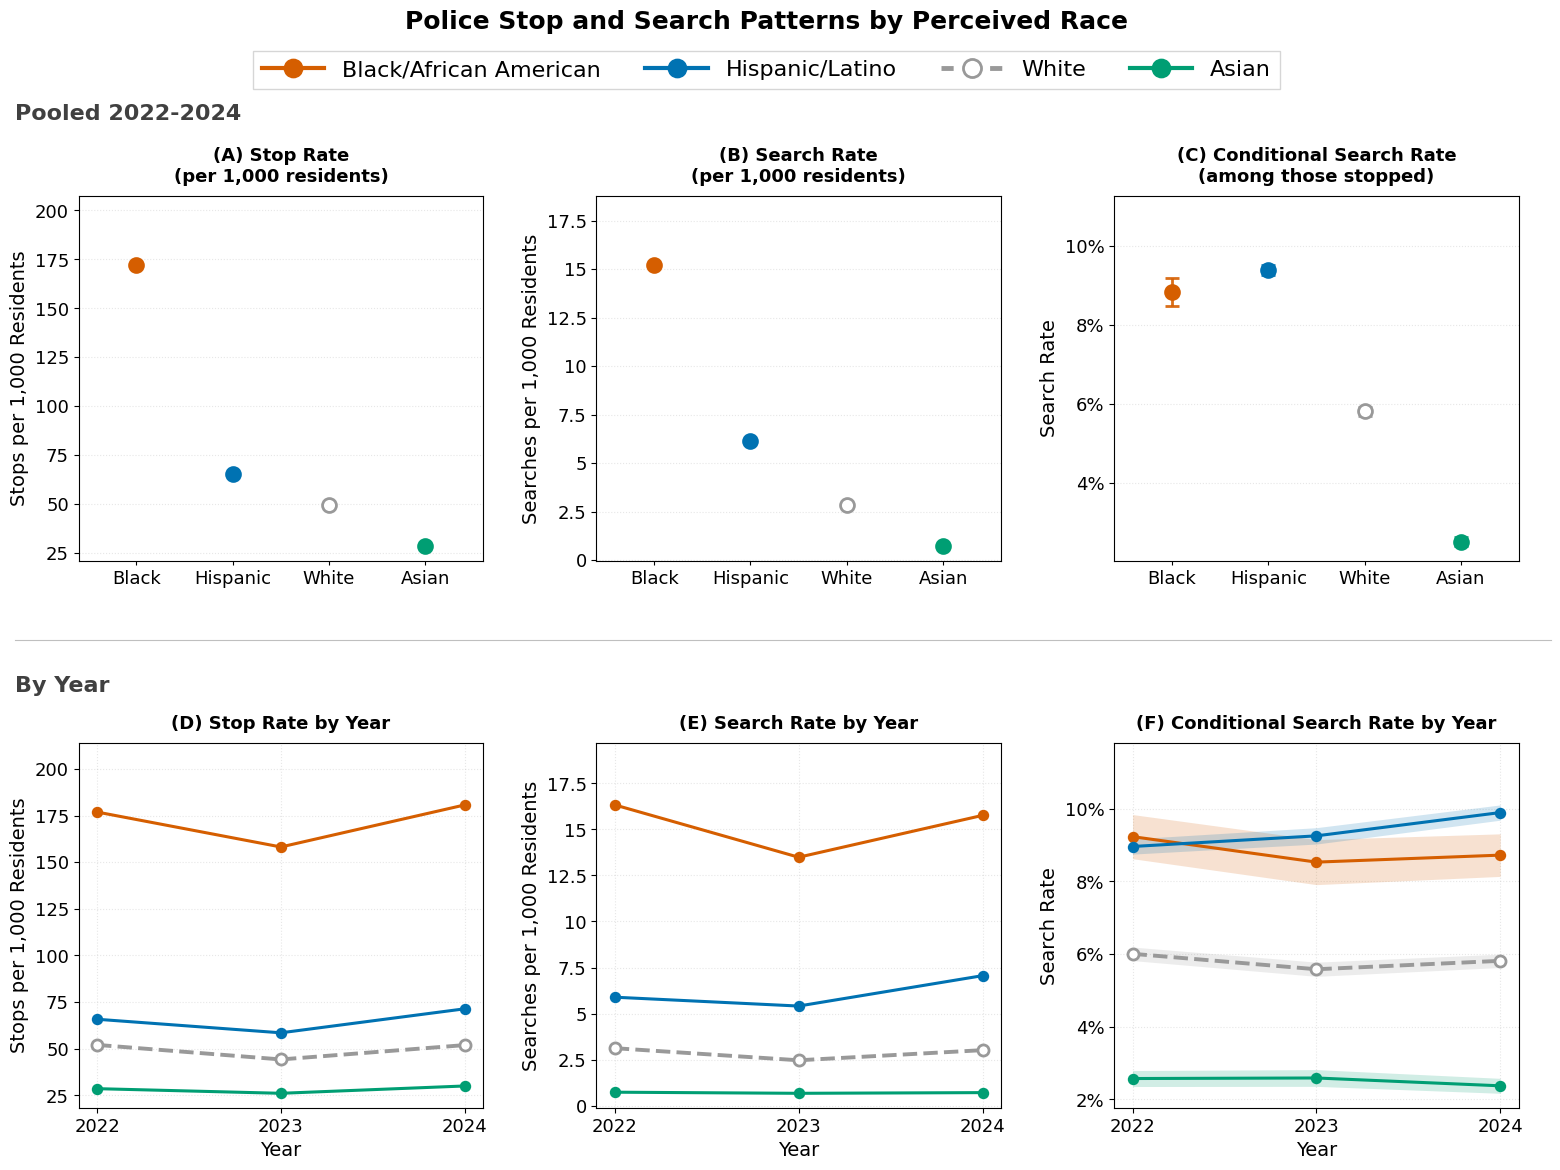

In [51]:
policing_figs = visualization_utils.plot_policing_by_year(policing_analysis)
# visualization_utils.export_figure_to_pdf(policing_figs, "policing")

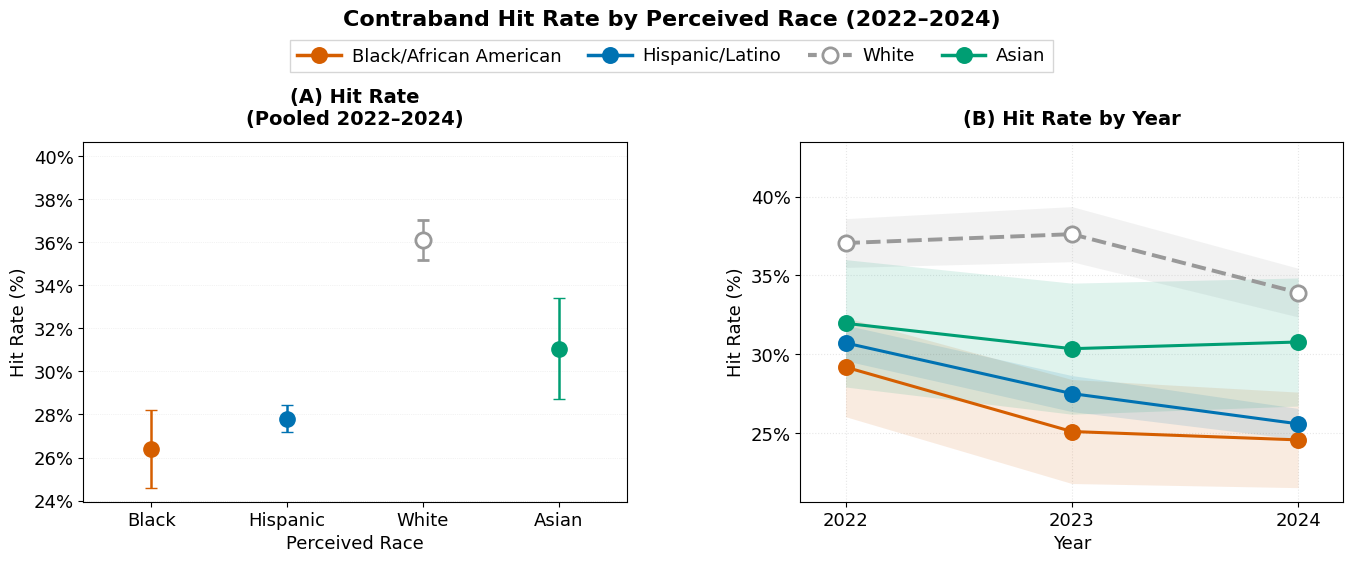

In [52]:
hit_rate_appendix_fig = visualization_utils.plot_hit_rate_by_year(policing_analysis)
# visualization_utils.export_figure_to_pdf(hit_rate_appendix_fig, "03_policing_hit")

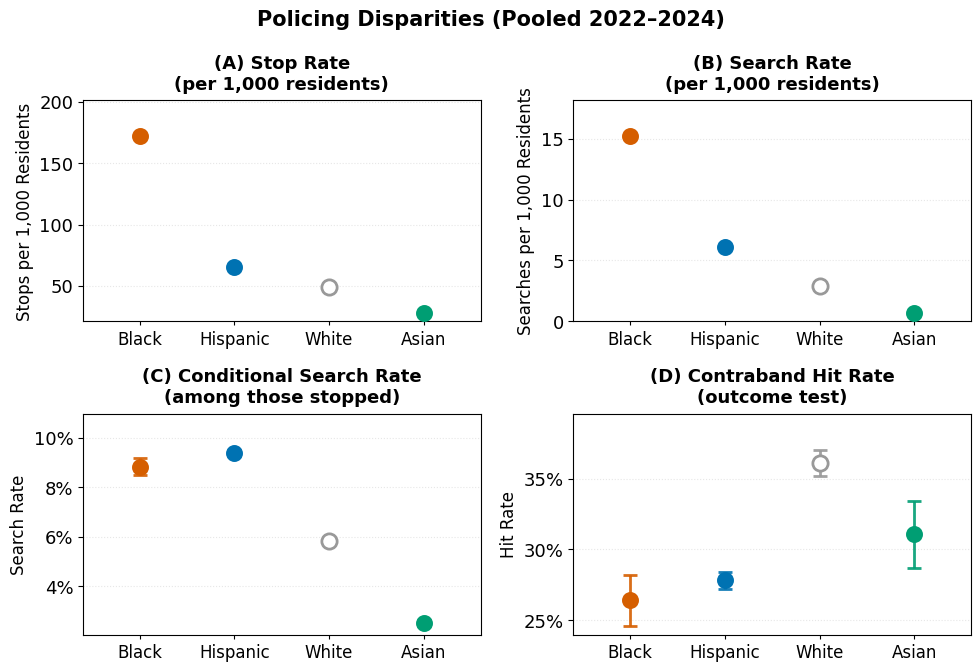

In [99]:
poster_02 = visualization_utils.plot_policing_pooled(policing_analysis)

# Policing Analysis: Stratified by Reason for Contact

In [54]:
# Calculate rates by reason for contact
policing_by_reason = analysis_utils.policing_rates_by_reason_for_contact(policing, census_coarse)

# Create comprehensive table with pooled 2022-2024 data
reason_table = table_utils.create_reason_for_contact_table(policing_by_reason)
display(reason_table)
# table_utils.export_reason_for_contact_table_to_latex(reason_table)

,Reason for Contact,Perceived Race,Stops,Searches,Search Rate (%),Hit Rate (%)
0,Moving violation,Black/African American,9754,323,3.31 (±0.36),18.27 (±4.21)
1,,Hispanic/Latino,93087,4782,5.14 (±0.14),17.04 (±1.07)
2,,White,97652,1586,1.62 (±0.08),28.06 (±2.21)
3,,Asian,38581,300,0.78 (±0.09),22.67 (±4.74)
4,,Other,21428,202,0.94 (±0.13),19.31 (±5.44)
5,Equipment violation,Black/African American,7054,615,8.72 (±0.66),20.98 (±3.22)
6,,Hispanic/Latino,62378,5943,9.53 (±0.23),25.81 (±1.11)
7,,White,33380,2560,7.67 (±0.29),35.23 (±1.85)
8,,Asian,9761,394,4.04 (±0.39),31.22 (±4.58)
9,,Other,5826,247,4.24 (±0.52),25.10 (±5.41)


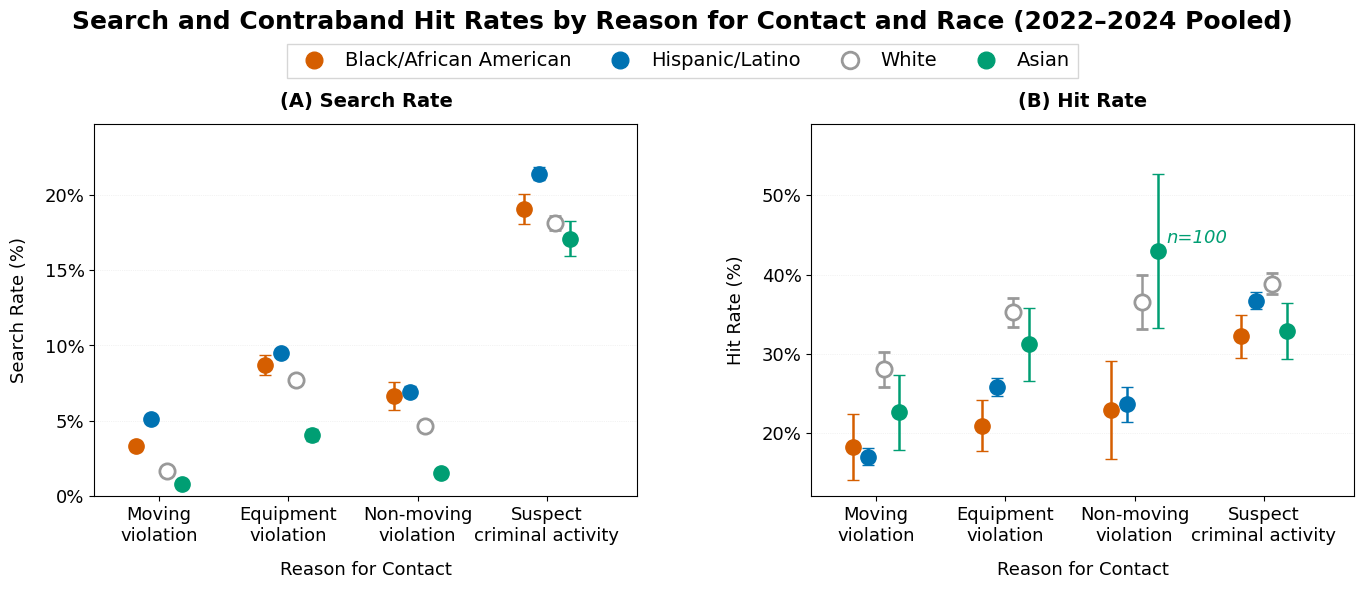

In [55]:
# Create search rate visualization
fig_search = visualization_utils.visualize_search_and_hit_rates_by_reason(policing_by_reason)
# visualization_utils.export_figure_to_pdf(fig_search, "03_policing_by_reason")

# Policing Analysis: Black and White Search/Hit Rates by Agency

In [56]:
# Calculate the White and Black search/hit rates for each agency and summarize in a table

agency_hit_summary = analysis_utils.summarize_agency_black_white_rates(policing)
publication_table  = table_utils.agency_black_white_rates_table(agency_hit_summary)
display(publication_table)

# table_utils.export_agency_hit_rates_to_latex(publication_table, agency_hit_summary)

,Agency,White Stops,White Searches,White Search Rate (%),White Hit Rate (%),Black Stops,Black Searches,Black Search Rate (%),Black Hit Rate (%)
0,Anaheim PD,16315,1248,7.6 (±0.4),35.9 (±2.7),3381,328,9.7 (±1.0),24.4 (±4.6)
1,Brea PD,2441,219,9.0 (±1.1),42.9 (±6.6),637,67,10.5 (±2.4),41.8 (±11.8)
2,Buena Park PD,3040,261,8.6 (±1.0),30.3 (±5.6),1566,142,9.1 (±1.4),23.2 (±6.9)
3,Cal State Fullerton PD,576,38,6.6 (±2.0),60.5 (±15.5),172,9,5.2 (±3.3),22.2 (±27.2)
4,Costa Mesa PD,15257,463,3.0 (±0.3),50.3 (±4.6),1506,77,5.1 (±1.1),31.2 (±10.3)
5,Cypress PD,1828,111,6.1 (±1.1),48.6 (±9.3),515,43,8.3 (±2.4),39.5 (±14.6)
6,Fountain Valley PD,2488,137,5.5 (±0.9),48.2 (±8.4),318,23,7.2 (±2.8),65.2 (±19.5)
7,Fullerton PD,5748,680,11.8 (±0.8),34.7 (±3.6),1325,223,16.8 (±2.0),26.5 (±5.8)
8,Garden Grove PD,2792,142,5.1 (±0.8),43.0 (±8.1),478,41,8.6 (±2.5),48.8 (±15.3)
9,Huntington Beach PD,9247,574,6.2 (±0.5),38.5 (±4.0),766,53,6.9 (±1.8),34.0 (±12.8)


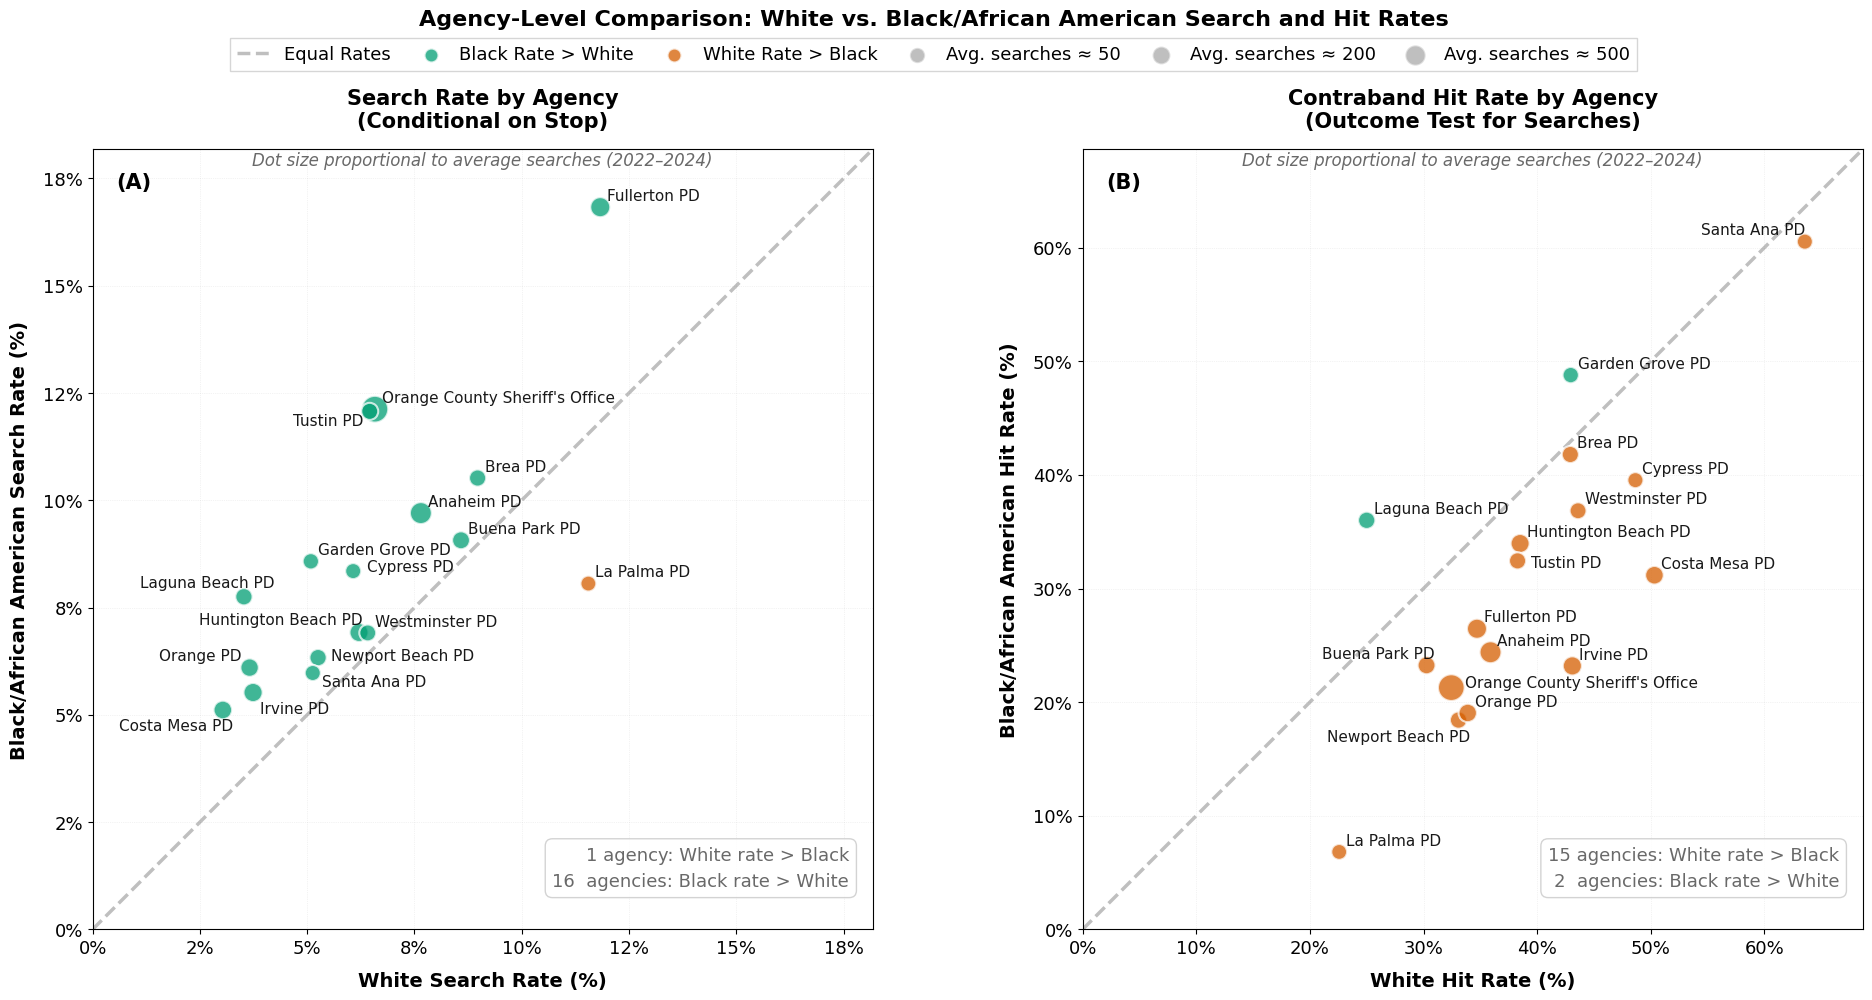

In [57]:
fig_agency = visualization_utils.plot_agency_black_white_rates(agency_hit_summary)
# visualization_utils.export_figure_to_pdf(fig_agency, "04_agency_rates")

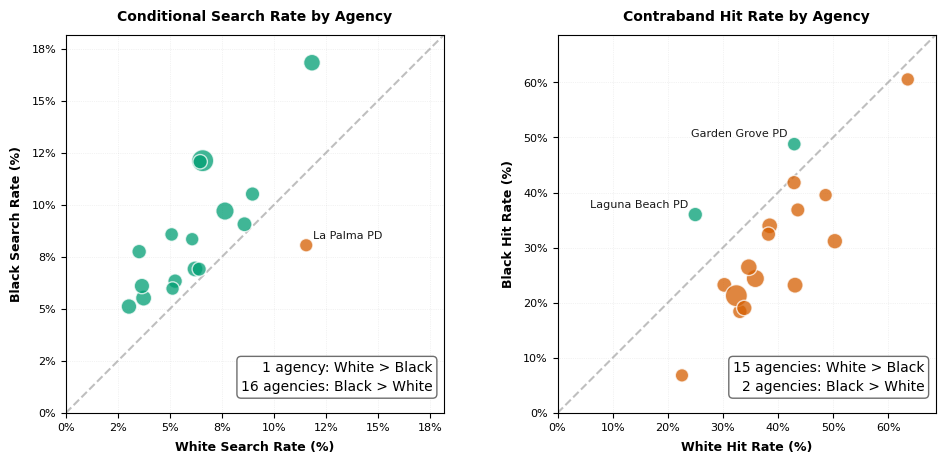

In [120]:
fig = visualization_utils.plot_agency_black_white_rates_poster(agency_hit_summary)

# Policing Sensitivity Analysis: Mixed Search Bases and Multiperson Stops

In [58]:
# Checks sensitivity of search and hit rates to including searches with mixed legal bases (e.g. "Mixed" or "No search basis") as discretionary searches

policing["disc_search_mixed"] = (
    policing["action_any_search"]
    & policing["search_type"].isin(["Discretionary only", "Mixed", "No search basis"])
)

policing["disc_hit_mixed"] = (
    policing["disc_search_mixed"]
    & policing["action_any_search"].fillna(False)
    & (policing["contraband_any"] == 1)
)

policing_analysis_mixed = analysis_utils.policing_rates_sensitivity(
    policing,
    census_coarse,
    "mixed"
)

# Checks sensitivity of search and hit rates to including all people involved in stops (not just person 1) for multiperson stops

policing_multi.rename(
    columns={"disc_search": "disc_search_multiperson"},
    inplace=True
)

policing_multi["disc_hit_multiperson"] = (
    policing_multi["disc_search_multiperson"]
    & policing_multi["action_any_search"].fillna(False)
    & (policing_multi["contraband_any"] == 1)
)

policing_analysis_multiperson = analysis_utils.policing_rates_sensitivity(
    policing_multi,
    census_coarse,
    "multiperson"
)

In [59]:
# Creates one table for 2024

def make_2024_block(df, label):
    """Return a 2024 table with formatted Search/Hit rates for one method."""
    d = df[df["Year"] == 2024].copy()
    d = d.set_index("Perceived Race")

    def special_fmt_est_ci(rate, se, digits=2):
        pct = rate * 100
        ci = 1.96 * se * 100
        return f"{pct:.{digits}f} (±{ci:.{digits}f})"

    out = pd.DataFrame(index=d.index)
    out[("Search Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Search Rate"], d["Search Rate SE"])
    ]
    out[("Hit Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Hit Rate"], d["Hit Rate SE"])
    ]
    return out

# Build 2024 display blocks
baseline_2024 = make_2024_block(policing_analysis.copy(), "Baseline")
mixed_2024 = make_2024_block(policing_analysis_mixed.copy(), "Mixed")
multiperson_2024 = make_2024_block(policing_analysis_multiperson.copy(), "Multiperson")

# Join into one combined display table
table3 = baseline_2024.join(mixed_2024, how="outer").join(multiperson_2024, how="outer")

# Enforce row order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table3 = table3.reindex(race_order)

# Enforce column order
table3 = table3[
    [
        ("Search Rate (%)", "Baseline"),
        ("Search Rate (%)", "Mixed"),
        ("Search Rate (%)", "Multiperson"),
        ("Hit Rate (%)", "Baseline"),
        ("Hit Rate (%)", "Mixed"),
        ("Hit Rate (%)", "Multiperson"),
    ]
]

table3.columns = pd.MultiIndex.from_tuples(table3.columns, names=["", ""])
table3.index.name = "Perceived Race"

table3
# export_combined_sensitivity_to_latex(policing_analysis, policing_analysis_mixed, policing_analysis_multiperson)

Search Rate (%)                                \
                              Baseline          Mixed    Multiperson   
Perceived Race                                                         
Black/African American    8.72 (±0.59)  12.46 (±0.69)   9.40 (±0.58)   
Hispanic/Latino           9.89 (±0.21)  13.15 (±0.24)  10.80 (±0.21)   
White                     5.81 (±0.18)   8.09 (±0.21)   6.55 (±0.19)   
Asian                     2.37 (±0.21)   3.13 (±0.24)   2.52 (±0.21)   
Other                     3.02 (±0.30)   3.92 (±0.34)   3.33 (±0.31)   

                         Hit Rate (%)                                
                             Baseline          Mixed    Multiperson  
Perceived Race                                                       
Black/African American  24.58 (±3.03)  28.92 (±2.67)  24.67 (±2.80)  
Hispanic/Latino         25.60 (±0.98)  30.50 (±0.89)  26.16 (±0.90)  
White                   33.91 (±1.54)  38.79 (±1.35)  34.12 (±1.41)  
Asian                   30.78 (±4.06)  35.06 (±3.65)  30.47 (±3.82)  
Other                   25.94 (±4.44)  27.63 (±3.98)  26.05 (±4.15)

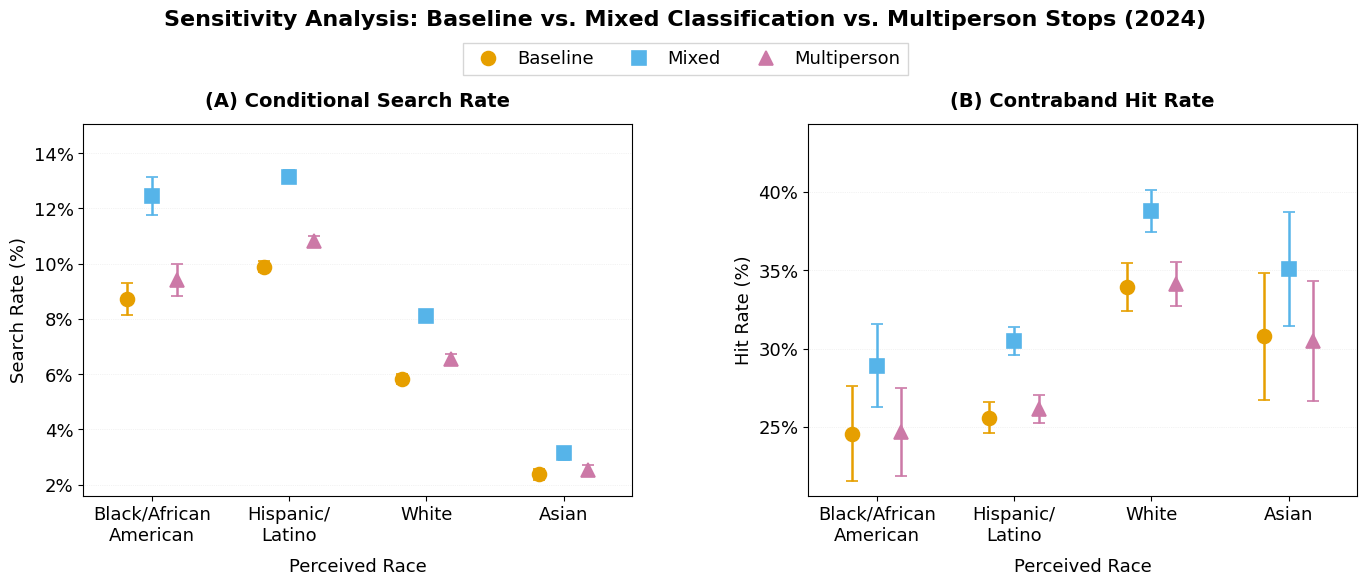

In [60]:
sensitivity_fig = visualization_utils.create_combined_sensitivity_visualization(
    policing_analysis,
    policing_analysis_mixed,
    policing_analysis_multiperson
)

# visualization_utils.export_figure_to_pdf(sensitivity_fig, "sensitivity")

# Prosecution Analysis: Enhancement Rates by Charge and Statute Level

In [61]:
# Harmonizes race labels
prosecution = analysis_utils.add_standardized_race(prosecution, 'canonical_race')

# Identify charges that are enhancements/priors/sentencing considerations rather than actual substantive criminal charges
prosecution['is_non_substantive'] = (
    prosecution['is_enhancement_charge'].astype(bool) |
    prosecution['is_special_circumstance'].astype(bool) |
    prosecution['is_sentencing_charge'].astype(bool)
)

# Apply categorization ONLY to substantive charges
prosecution.loc[~prosecution['is_non_substantive'], 'charge_category'] = \
    prosecution.loc[~prosecution['is_non_substantive'], 'charge_description'].apply(analysis_utils.categorize_charge)
prosecution.loc[prosecution['is_non_substantive'], 'charge_category'] = 'Enhancement/Prior/Sentencing'

# Each case is a single defendant, so case-level = defendant-case-level
# For each case, if any charge is an enhancement charge, then the case is flagged as having an enhancement charge
# Original - no 23152 exclusion needed here
enh_flag = (
    prosecution[prosecution["is_enhancement_charge"]]
    .groupby("source_case_id")["is_enhancement_charge"]
    .max()
    .rename("any_enhancement_in_case")
    .reset_index()
)

# Filter for only substantive charges for the main analysis, but keep enhancement flag
substantive = prosecution[~prosecution['is_non_substantive']].copy()
substantive = substantive.merge(enh_flag, on='source_case_id', how='left')
substantive['any_enhancement_in_case'] = substantive['any_enhancement_in_case'].fillna(0).astype(int)

# Assign primary charge category
primary = analysis_utils.assign_primary_charge_by_severity(substantive)
substantive = substantive.merge(primary, on='source_case_id', how='left')


In [62]:
# Cases where the primary charge category is DUI
dui_cases = substantive[substantive["primary_charge_category"] == "DUI"]["source_case_id"].unique()

# Among those, which have any enhancement flag
dui_with_enhancement = prosecution[
    (prosecution["source_case_id"].isin(dui_cases)) &
    (prosecution["is_enhancement_charge"])
]

print(f"Total DUI cases: {len(dui_cases):,}")
print(f"DUI cases with any enhancement charge: {dui_with_enhancement['source_case_id'].nunique():,}")
print(f"Pct: {dui_with_enhancement['source_case_id'].nunique() / len(dui_cases):.1%}")

# Then look at what those enhancement statutes actually are
print("\nTop enhancement statutes in DUI cases:")
print(dui_with_enhancement["statute"].value_counts().head(20))

Total DUI cases: 16,433
DUI cases with any enhancement charge: 15,172
Pct: 92.3%

Top enhancement statutes in DUI cases:
statute
23152(A)     16165
20001(C)         5
186.22(D)        4
241(C)           1
241(B)           1
Name: count, dtype: int64


In [63]:
substantive_full = substantive.copy()

# DUI cases excluded: enhancement flag reflects DA's standard practice of jointly
# filing VC 23152(a) and VC 23152(b) as paired counts, not traditional enhancements
substantive = substantive[~substantive["source_case_id"].isin(dui_cases)].copy()

enhancement_by_primary = analysis_utils.enhancement_rates_by_primary_severity(substantive)

filtered_enhancement = enhancement_by_primary[
    enhancement_by_primary["primary_charge_category"] != "Other"
].copy()

# Only include the following categories
allowed_categories = [
    "Assault/Violence",
    "Weapons",
    "Obstruct/Resist Officer"
]
filtered_enhancement = filtered_enhancement[filtered_enhancement["primary_charge_category"].isin(allowed_categories)].copy()

In [64]:
# Table 1: By race and statute level
# enhancement_combined = table_utils.enhancement_rate_combined_table(enhancement_by_primary)
# display(enhancement_combined)

# Table 2: By race, statute level, and primary category (for all categories)
# Excludes the "Other" category
enhancement_category = table_utils.enhancement_rate_race_statute_category_table(filtered_enhancement)
display(enhancement_category)

# table_utils.export_enhancement_category_table_to_latex(enhancement_category)

,Charge Category,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,Assault/Violence,Black/African American,Misdemeanor,335,8.06 (±2.92)
1,,,Felony,183,14.75 (±5.14)
2,,Hispanic/Latino,Misdemeanor,2411,7.84 (±1.07)
3,,,Felony,1145,15.46 (±2.09)
4,,White,Misdemeanor,1761,7.44 (±1.23)
5,,,Felony,565,11.33 (±2.61)
6,,Asian,Misdemeanor,325,3.69 (±2.05)
7,,,Felony,96,11.46 (±6.37)
8,,Other,Misdemeanor,239,2.93 (±2.14)
9,,,Felony,81,13.58 (±7.46)


In [65]:
# Plot: By race and statute level

# without_other = enhancement_by_primary[enhancement_by_primary["race_std"] != "Other"].copy()
# enhancement_rate_race_statute = visualization_utils.plot_enhancement_rate_by_race_statute(without_other)
# visualization_utils.export_figure_to_pdf(enhancement_rate_race_statute, "enhancement_rate_by_race_statute")

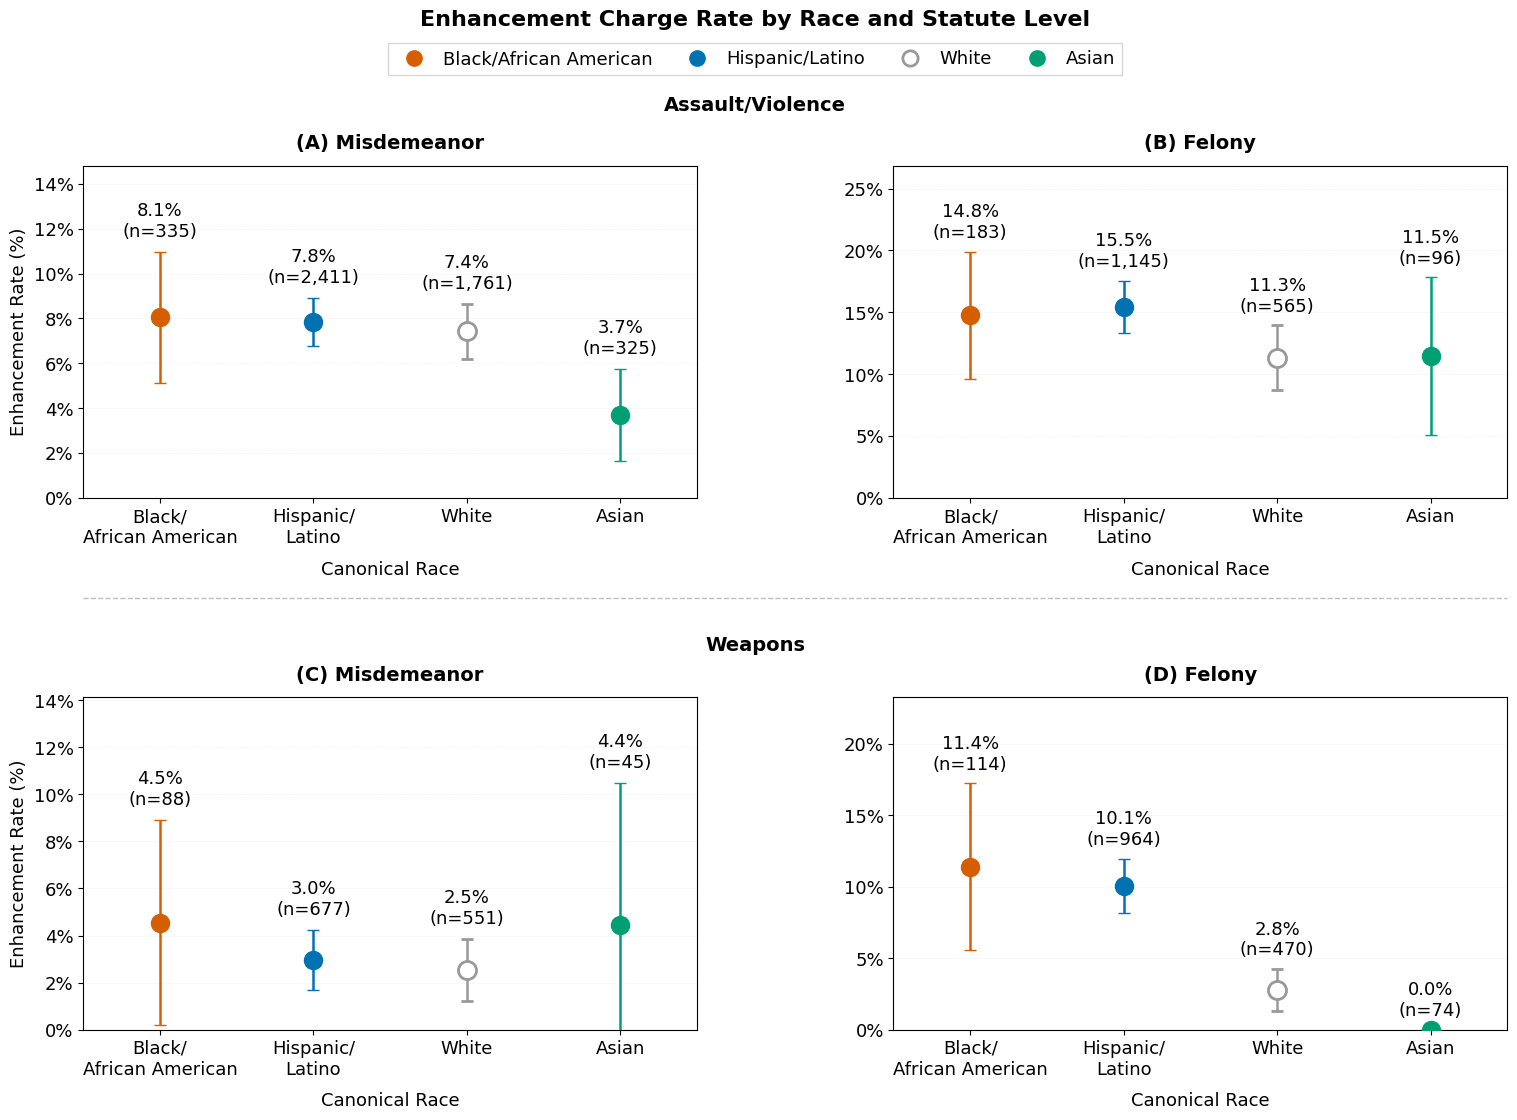

In [66]:
figs = visualization_utils.plot_enhancement_rate_by_race_statute_category(enhancement_by_primary)
# visualization_utils.export_figure_to_pdf(figs["assault_violence_weapons"], "enhancement_assault_violence_weapons")

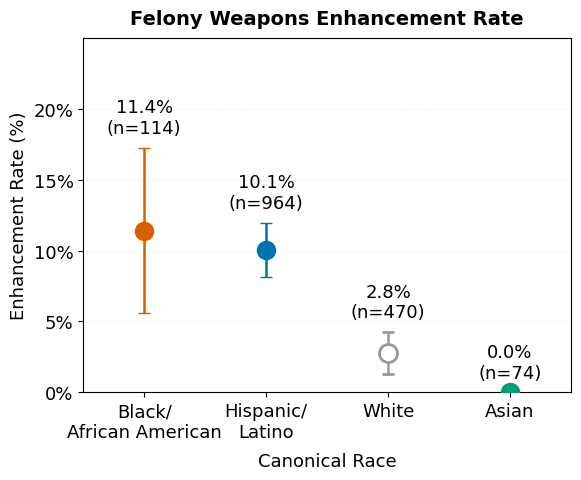

In [91]:
fig = visualization_utils.plot_weapons_felony_enhancement(enhancement_by_primary)

# Prosecution Analysis: Enhancement Rates by Statute

In [68]:
def normalize_statute(s):
    """Extract base statute number (e.g. '186.22' from '186.22(B)(1)')."""
    if pd.isna(s):
        return None
    s = str(s).strip()
    match = re.match(r"^([\d]+(?:\.[\d]+)?)", s)
    return match.group(1) if match else None


# Get enhancement charges from non-DUI cases
enhancement_rows = prosecution[
    prosecution["is_enhancement_charge"] &
    ~prosecution["source_case_id"].isin(dui_cases)
].copy()

# Nomralize statute numbers to base
enhancement_rows["statute_normalized"] = enhancement_rows["statute"].apply(normalize_statute)

# Calculate total count and % of all enhancements per statute
statute_totals = (
    enhancement_rows
    .groupby("statute_normalized")
    .size()
    .reset_index(name="total")
)
statute_totals["pct"] = (
    statute_totals["total"] / statute_totals["total"].sum() * 100
).round(1)

# Calculate the total non-DUI cases per race (denominator for rates)
total_cases_by_race = (
    substantive
    .drop_duplicates("source_case_id")
    .groupby("race_std")
    .size()
    .rename("total_cases")
    .reset_index()
)

# Calculate cases with each statute per race (numerator)
# Use nunique on source_case_id to avoid double-counting multi-charge cases
statute_rate_by_race = (
    enhancement_rows
    .groupby(["statute_normalized", "race_std"])
    ["source_case_id"].nunique()
    .reset_index(name="cases_with_statute")
)

# Compute rates and binomial CIs
statute_rate_by_race = statute_rate_by_race.merge(
    total_cases_by_race, on="race_std", how="left"
)

statute_rate_by_race["rate"] = (
    statute_rate_by_race["cases_with_statute"] /
    statute_rate_by_race["total_cases"]
)
statute_rate_by_race["se"] = np.sqrt(
    statute_rate_by_race["rate"] *
    (1 - statute_rate_by_race["rate"]) /
    statute_rate_by_race["total_cases"]
)

# Formatting CIs
statute_rate_by_race["rate_fmt"] = statute_rate_by_race.apply(
    lambda row: f"{row['rate']*100:.2f} (±{row['se']*1.96*100:.2f})",
    axis=1
)

# Pivot rates to wide format
rates_wide = (
    statute_rate_by_race
    .pivot(index="statute_normalized", columns="race_std", values="rate_fmt")
)

# Filter to statutes with minimum total of 50 enhancement charges to ensure stable rate estimates
MIN_COUNT = 50
eligible_statutes = statute_totals[
    statute_totals["total"] >= MIN_COUNT
]["statute_normalized"].tolist()

# Filter to statutes with meaningful racial variation
# Keep only statutes where at least one Black/Hispanic vs White comparison has non-overlapping 95% CIs

def has_meaningful_disparity(statute, df, comparison_pairs):
    """
    Returns True if any comparison pair has non-overlapping CIs
    for the given statute.
    """
    sub = df[df["statute_normalized"] == statute].set_index("race_std")
    
    for race_a, race_b in comparison_pairs:
        if race_a not in sub.index or race_b not in sub.index:
            continue
        
        lo_a = sub.loc[race_a, "rate"] - 1.96 * sub.loc[race_a, "se"]
        hi_a = sub.loc[race_a, "rate"] + 1.96 * sub.loc[race_a, "se"]
        lo_b = sub.loc[race_b, "rate"] - 1.96 * sub.loc[race_b, "se"]
        hi_b = sub.loc[race_b, "rate"] + 1.96 * sub.loc[race_b, "se"]
        
        # Non-overlapping if one interval is entirely above the other
        if lo_a > hi_b or lo_b > hi_a:
            return True
    
    return False

# Check Black vs White and Hispanic vs White
COMPARISON_PAIRS = [
    ("Black/African American", "White"),
    ("Hispanic/Latino", "White"),
]

statutes_with_disparity = [
    s for s in eligible_statutes
    if has_meaningful_disparity(s, statute_rate_by_race, COMPARISON_PAIRS)
    and s not in ["23152", "417"] # To see why 417 is excluded, see cell below
]

print("Statutes with sufficient counts AND meaningful racial disparity:")
print(statutes_with_disparity)

# Use these as your focus statutes instead of hardcoding
FOCUS_STATUTES = statutes_with_disparity

Statutes with sufficient counts AND meaningful racial disparity:
['12022.5', '12022.53', '186.22']


In [69]:
# What primary charge categories do cases with 417 enhancements have?
cases_with_417 = (
    enhancement_rows[enhancement_rows["statute_normalized"] == "417"]
    ["source_case_id"].unique()
)

print("Primary categories of cases with 417 enhancement charges:")
print(
    primary[primary["source_case_id"].isin(cases_with_417)]
    ["primary_charge_category"].value_counts()
)

# Also check which specific 417 subsections appear
print("\n417 subsections present:")
print(
    enhancement_rows[enhancement_rows["statute_normalized"] == "417"]
    ["statute"].value_counts()
)

# These results show that all 417 subsections are from general brandishing in public
# Which is a substantive brandishing charge, not a sentencing enhancement

Primary categories of cases with 417 enhancement charges:
primary_charge_category
Assault/Violence                   168
Theft/Burglary/Robbery              33
Drug Possession/Paraphernalia       22
Weapons                             18
Vandalism                           15
Disorderly Conduct/Public Order     12
Obstruct/Resist Officer             11
Sex Offense/Registration             4
Other                                1
Name: count, dtype: int64

417 subsections present:
statute
417(A)(1)    492
Name: count, dtype: int64


In [70]:
STATUTE_DESCRIPTIONS = {
    "186.22":   "Gang Enhancement",
    "12022.5":  "Firearm Use",
    "12022.53": "Firearm Use in Serious Felony"
}

# Create table
consolidated = (
    statute_totals
    .set_index("statute_normalized")
    .join(rates_wide)
    .loc[FOCUS_STATUTES]
    .reset_index()
)

consolidated.insert(1, "Description",
    consolidated["statute_normalized"].map(STATUTE_DESCRIPTIONS)
)

consolidated = consolidated.rename(columns={
    "statute_normalized":     "Statute",
    "total":                  "Total",
    "pct":                    "% of Enhancements",
    "Black/African American": "Black/African American",
    "Hispanic/Latino":        "Hispanic/Latino",
    "White":                  "White",
    "Asian":                  "Asian",
})

consolidated = consolidated[[
    "Statute",
    "Description", 
    "Total",
    "% of Enhancements",
    "Black/African American",
    "Hispanic/Latino",
    "White",
    "Asian",
    "Other",
]]
consolidated = consolidated.fillna("---")
consolidated = consolidated.sort_values("Total", ascending=False).reset_index(drop=True)

display(consolidated)

# table_utils.export_statute_table_to_latex(consolidated)

,Statute,Description,Total,% of Enhancements,Black/African American,Hispanic/Latino,White,Asian,Other
0,186.22,Gang Enhancement,920,18.0,0.11 (±0.11),0.63 (±0.09),0.04 (±0.03),---,0.08 (±0.11)
1,12022.5,Firearm Use,188,3.7,0.31 (±0.18),0.18 (±0.05),0.07 (±0.03),0.14 (±0.14),0.20 (±0.18)
2,12022.53,Firearm Use in Serious Felony,183,3.6,0.28 (±0.17),0.13 (±0.04),0.05 (±0.03),0.14 (±0.14),0.04 (±0.08)


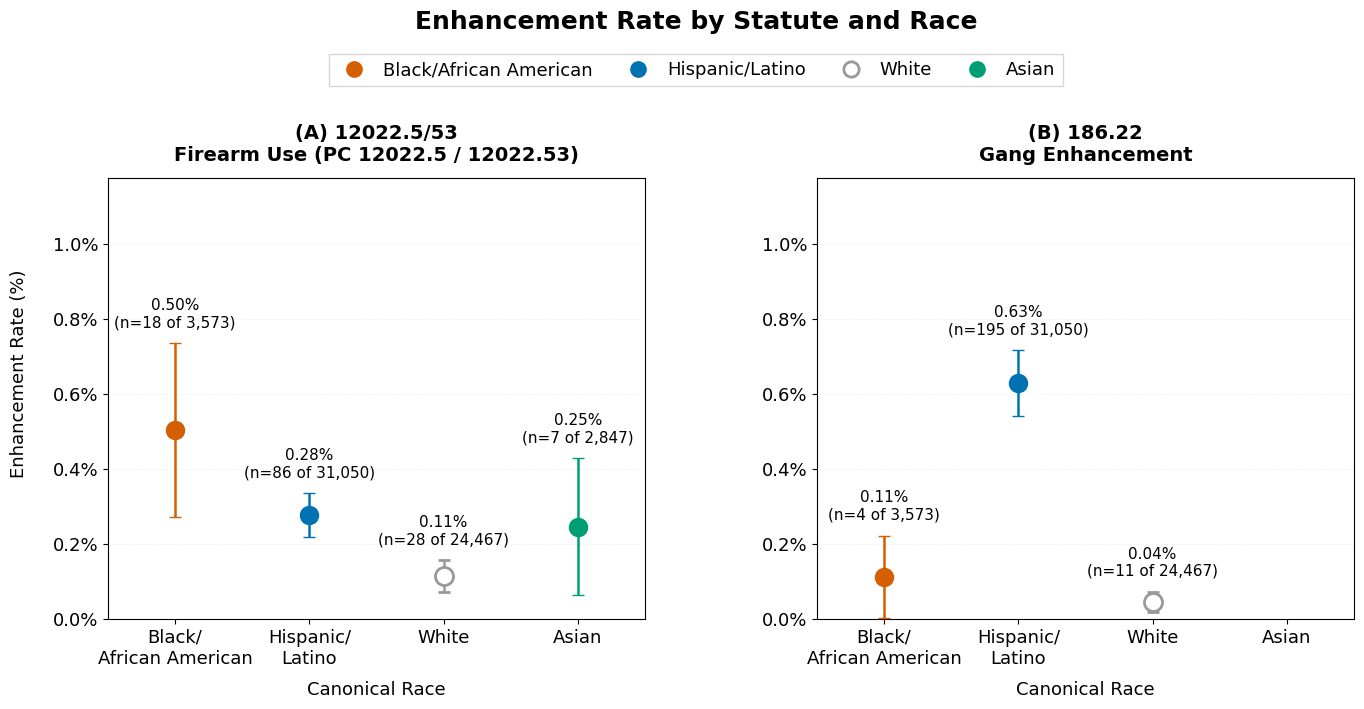

In [71]:
# Get all case IDs that have either a 12022.5 or 12022.53 enhancement charge
firearm_cases = set(
    enhancement_rows[
        enhancement_rows["statute_normalized"].isin(["12022.5", "12022.53"])
    ]["source_case_id"].unique()
)

# Build a combined "any firearm use" row for each race group
firearm_rate_rows = []
for race in ["Black/African American", "Hispanic/Latino", "White", "Asian"]:
    # Total non-DUI cases for this race group (denominator)
    total = total_cases_by_race.set_index("race_std").loc[race, "total_cases"]
    
    # Cases belonging to this race that have a firearm enhancement charge (numerator)
    n = len([
        c for c in firearm_cases
        if c in set(
            enhancement_rows[enhancement_rows["race_std"] == race]["source_case_id"]
        )
    ])

    # Enhancement rate for this race group
    rate = n / total

    # Binomial standard error
    se = np.sqrt(rate * (1 - rate) / total)

    # Append one row per race group
    firearm_rate_rows.append({
        "statute_normalized": "12022.5/53",
        "race_std": race,
        "cases_with_statute": n,
        "total_cases": total,
        "rate": rate,
        "se": se,
        "rate_fmt": f"{rate*100:.2f} (±{se*1.96*100:.2f})",
    })

# Append the combined firearm rows to the existing statute rate table
statute_rate_by_race_combined = pd.concat(
    [statute_rate_by_race, pd.DataFrame(firearm_rate_rows)],
    ignore_index=True,
)

# Define which statutes to plot
FOCUS_STATUTES_COMBINED = ["12022.5/53", "186.22"]
STATUTE_DESCRIPTIONS_COMBINED = {
    "12022.5/53": "Firearm Use (PC 12022.5 / 12022.53)",
    "186.22":     "Gang Enhancement",
}

# Generate figure
fig_statutes = visualization_utils.plot_enhancement_by_statute(
    statute_rate_by_race_combined,
    focus_statutes=FOCUS_STATUTES_COMBINED,
    statute_descriptions=STATUTE_DESCRIPTIONS_COMBINED,
    total_cases_by_race=total_cases_by_race,
)

# visualization_utils.export_figure_to_pdf(fig_statutes, "enhancement_by_statute")

In [72]:
# Cases with 12022.5 enhancement
cases_12022_5 = set(
    enhancement_rows[enhancement_rows["statute_normalized"] == "12022.5"]
    ["source_case_id"].unique()
)

# Cases with 12022.53 enhancement
cases_12022_53 = set(
    enhancement_rows[enhancement_rows["statute_normalized"] == "12022.53"]
    ["source_case_id"].unique()
)

# Overlap
both = cases_12022_5 & cases_12022_53
either = cases_12022_5 | cases_12022_53

print(f"Cases with 12022.5:         {len(cases_12022_5):,}")
print(f"Cases with 12022.53:        {len(cases_12022_53):,}")
print(f"Cases with both:            {len(both):,}")
print(f"Cases with either:          {len(either):,}")
print(f"Overlap as % of 12022.5:   {len(both)/len(cases_12022_5):.1%}")
print(f"Overlap as % of 12022.53:  {len(both)/len(cases_12022_53):.1%}")

Cases with 12022.5:         92
Cases with 12022.53:        67
Cases with both:            18
Cases with either:          141
Overlap as % of 12022.5:   19.6%
Overlap as % of 12022.53:  26.9%


# Prosecution Analysis: Wobblers

In [73]:
filtered_wobbler_categories = analysis_utils.get_filtered_wobbler_categories(substantive_full)
wobbler_combined = table_utils.wobbler_felony_rate_tables(substantive_full)
display(wobbler_combined)
# table_utils.export_wobbler_combined_to_latex(wobbler_combined)

Total Wobblers  \
Charge Category           Canonical Race                           
Overall                   Black/African American            5684   
                          Hispanic/Latino                  49976   
                          White                            35432   
                          Asian                             4517   
                          Other                             4532   
Theft/Burglary/Robbery    Black/African American            1659   
                          Hispanic/Latino                  11065   
                          White                             5890   
                          Asian                              834   
                          Other                              752   
Assault/Violence          Black/African American             838   
                          Hispanic/Latino                   5395   
                          White                             2736   
                          Asian                              485   
                          Other                              361   
Fraud/Identity Theft      Black/African American             296   
                          Hispanic/Latino                   2398   
                          White                             2493   
                          Asian                              472   
                          Other                              961   
Weapons                   Black/African American             289   
                          Hispanic/Latino                   2857   
                          White                             1407   
                          Asian                              214   
                          Other                              133   
Vandalism                 Black/African American             244   
                          Hispanic/Latino                   2196   
                          White                             1166   
                          Asian                              215   
                          Other                              162   
Vehicle-Related (non-DUI) Black/African American              77   
                          Hispanic/Latino                    790   
                          White                              360   
                          Asian                               34   
                          Other                               90   
Obstruct/Resist Officer   Black/African American             134   
                          Hispanic/Latino                    699   
                          White                              350   
                          Asian                               51   
                          Other                               57   

                                                  Filed as Felony  \
Charge Category           Canonical Race                            
Overall                   Black/African American             2927   
                          Hispanic/Latino                   21438   
                          White                             11179   
                          Asian                              1912   
                          Other                              2124   
Theft/Burglary/Robbery    Black/African American             1406   
                          Hispanic/Latino                    9271   
                          White                              4520   
                          Asian                               686   
                          Other                               587   
Assault/Violence          Black/African American              494   
                          Hispanic/Latino                    3388   
                          White                              1337   
                          Asian                               254   
                          Other                               166   
Fraud/Identity Theft

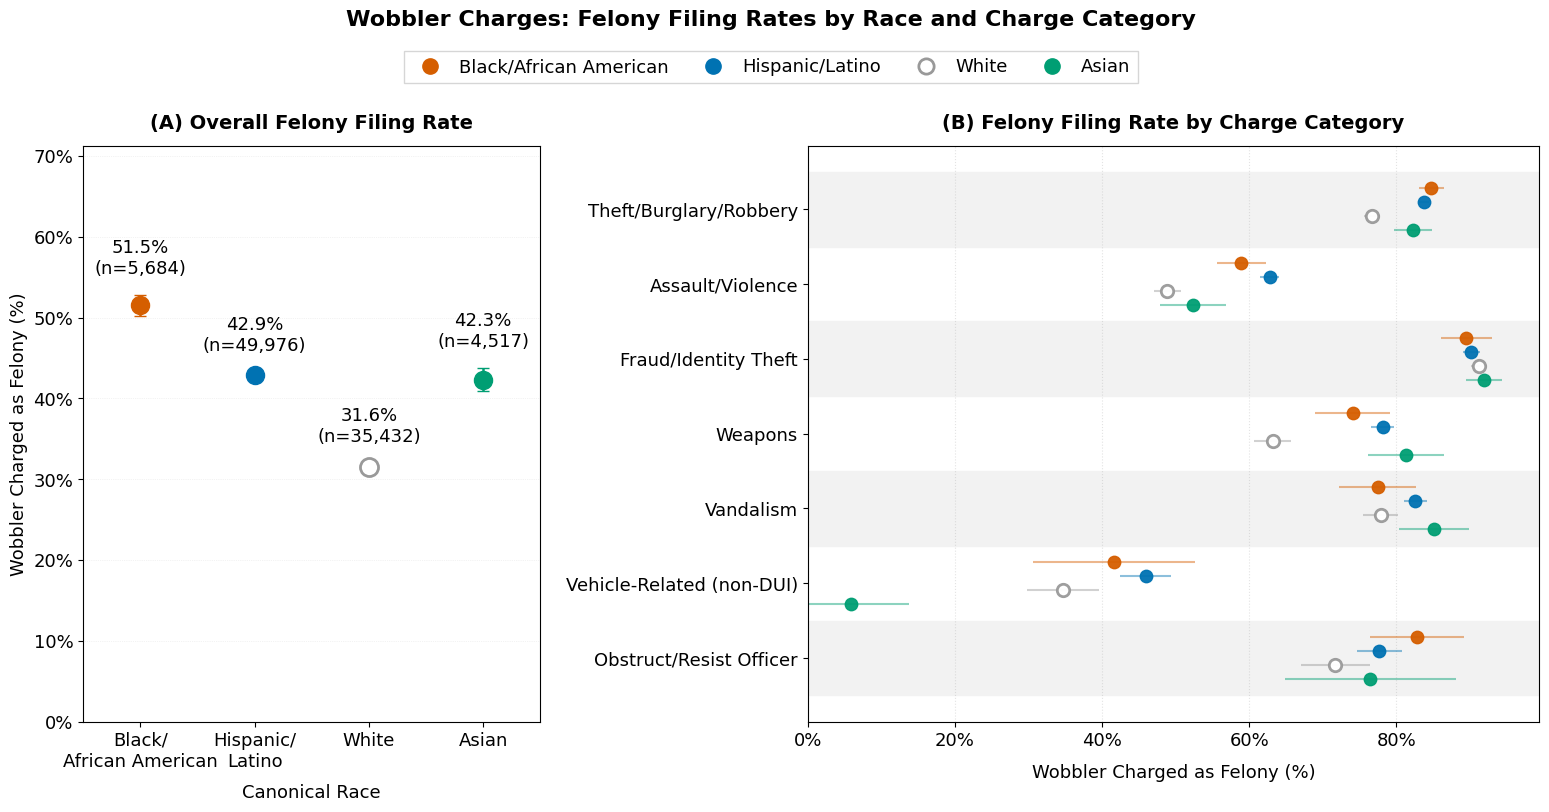

In [74]:
fig = visualization_utils.plot_wobbler_combined(substantive_full, top_categories=filtered_wobbler_categories, sort_by="rate_overall")
# visualization_utils.export_figure_to_pdf(fig, "wobblers")

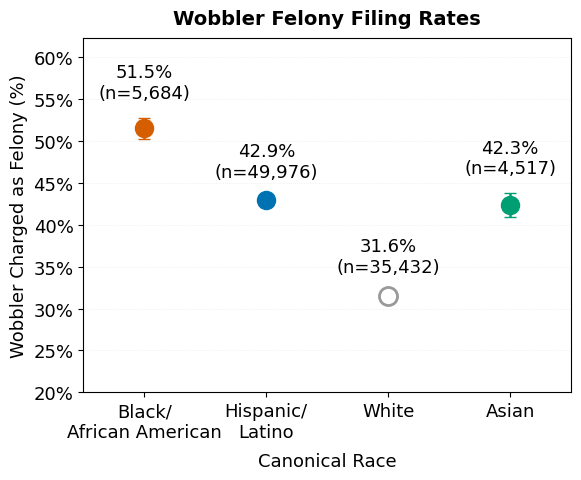

In [92]:
fig = visualization_utils.plot_wobbler_overall(substantive_full)

# Policing: Risk-Adjusted Regression

In [76]:
# Analyze only discretionary searchs
searched = policing[policing["disc_search"]].copy()
searched["hit"] = searched["disc_hit"].astype(int)

In [77]:
# Feature engineering

# Bin time of stop
searched["_hour"] = searched["time_of_stop"].str[:2].astype(int)

def hour_to_period(h):
    if h < 6:
        return "Night"
    elif h < 12:
        return "Morning"
    elif h < 18:
        return "Afternoon"
    elif h < 21:
        return "Evening"
    else:
        return "Night"

searched["time_period"] = searched["_hour"].map(hour_to_period)

# Bin stop duration
def duration_to_bin(d):
    if d < 10:
        return "Under 10 min"
    elif d <= 20:
        return "10-20 min"
    elif d <= 30:
        return "20-30 min"
    else:
        return "30+ min"

searched["duration_bin"] = searched["stop_duration"].apply(duration_to_bin)


# Combine traffic + suspicion offsense codes into one, flagging missingness explicitly
top_codes = (
    searched["offense_code"]
    .value_counts()
    .head(20)
    .index
)
searched["offense_code_grouped"] = searched["offense_code"].where(
    searched["offense_code"].isin(top_codes), other="OTHER"
)
policing["offense_code_grouped"] = policing["offense_code"].where(
    policing["offense_code"].isin(top_codes), other="OTHER"
)

KeyError: 'offense_code'

In [ ]:
# Choose features for modeling
categorical_cols = [
    "reason_for_contact",
    "time_period",
    "duration_bin",
    "agency_name",
    "year",
    "gender",
    "closest_city",
    "offense_code_grouped",
]

numeric_cols = ["age"]

# One hot encode categorical features, dropping the first category to avoid multicollinearity, and keeping numeric features as is

searched = searched.reset_index(drop=True)

# One hot encode categorical features
X_searched = pd.get_dummies(
    searched[categorical_cols].astype(str),
    drop_first=True,
    dtype=int
)

X_searched = pd.concat(
    [X_searched, searched[numeric_cols]],
    axis=1
)

y_searched = searched["hit"].values

In [ ]:
# Train on 2022-2023, test on 2024
searched = searched.reset_index(drop=True)
train_mask = searched["year"].isin([2022, 2023])
test_mask  = searched["year"] == 2024

X_train = X_searched[train_mask].reset_index(drop=True)
X_test  = X_searched[test_mask].reset_index(drop=True)
y_train = y_searched[train_mask.values]
y_test  = y_searched[test_mask.values]

In [ ]:
# Fit logistic regression on training set
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"))
])

pipe.fit(X_train, y_train)

# Evaluate on test set
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
y_pred       = pipe.predict(X_test)

print(f"Test AUC:  {roc_auc_score(y_test, y_pred_proba):.3f}")
print(classification_report(y_test, y_pred))

In [ ]:
# ── Apply same feature engineering to full policing dataframe ─────────────────
policing = policing.reset_index(drop=True)

policing["_hour"]       = policing["time_of_stop"].str[:2].astype(int)
policing["time_period"] = policing["_hour"].map(hour_to_period)
policing["duration_bin"] = policing["stop_duration"].apply(duration_to_bin)
policing["offense_code"] = (
    policing["traffic_violation_cjis_offense_code"]
    .fillna(policing["suspicion_cjis_offense_code"])
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
)
policing["offense_code_missing"] = (
    policing["traffic_violation_cjis_offense_code"].isna() &
    policing["suspicion_cjis_offense_code"].isna()
).astype(int)

# Build feature matrix for full policing dataframe
X_all = pd.get_dummies(
    policing[categorical_cols].astype(str),
    drop_first=True,
    dtype=int
)
X_all = pd.concat([X_all, policing[numeric_cols]], axis=1)

# Align columns to match training features exactly
X_all = X_all.reindex(columns=X_searched.columns, fill_value=0)

# Generate risk scores
policing["predicted_risk"] = pipe.predict_proba(X_all)[:, 1]

print(f"Risk score summary:")
print(policing.groupby("race_std")["predicted_risk"].describe().round(3))

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
COLOR_MAP = {
    "Black/African American": "#D55E00", # Dark orange
    "Hispanic/Latino": "#0072B2", # Dark blue
    "White": "#999999", # Gray
    "Asian": "#009E73" # Green
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

race_order_plot = ["Black/African American", "Hispanic/Latino", "White", "Asian"]

# ── Plot 1: Risk score distributions by race ──────────────────────────────────
ax = axes[0]
for race in race_order_plot:
    subset = policing[policing["race_std"] == race]["predicted_risk"]
    color  = COLOR_MAP.get(race, "#7f7f7f")
    is_white = race == "White"
    ax.hist(
        subset,
        bins=50,
        alpha=0.5,
        color=color,
        label=race,
        density=True,
        histtype="stepfilled" if not is_white else "step",
        linewidth=2.0 if is_white else 1.0,
    )
ax.set_xlabel("Predicted Risk Score", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("(A) Risk Score Distribution\nby Race", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle=":", linewidth=0.5)
ax.set_axisbelow(True)

# ── Plot 2: Search rate by risk quintile and race ─────────────────────────────
ax = axes[1]

policing["risk_quintile"] = pd.qcut(
    policing["predicted_risk"],
    q=5,
    labels=["Q1\n(Lowest)", "Q2", "Q3", "Q4", "Q5\n(Highest)"]
)

quintile_rates = (
    policing[policing["race_std"].isin(race_order_plot)]
    .groupby(["risk_quintile", "race_std"], observed=True)
    .agg(
        stops=("disc_search", "size"),
        searches=("disc_search", "sum")
    )
    .reset_index()
)
quintile_rates["search_rate"] = (
    quintile_rates["searches"] / quintile_rates["stops"] * 100
)
quintile_rates["se"] = np.sqrt(
    (quintile_rates["search_rate"] / 100) *
    (1 - quintile_rates["search_rate"] / 100) /
    quintile_rates["stops"]
) * 100

quintiles = quintile_rates["risk_quintile"].cat.categories.tolist()
x = np.arange(len(quintiles))
offsets = {"Black/African American": -0.27, "Hispanic/Latino": -0.09,
           "White": 0.09, "Asian": 0.27}

for race in race_order_plot:
    sub      = quintile_rates[quintile_rates["race_std"] == race].set_index("risk_quintile").reindex(quintiles)
    color    = COLOR_MAP.get(race, "#7f7f7f")
    is_white = race == "White"
    ax.errorbar(
        x + offsets[race],
        sub["search_rate"],
        yerr=sub["se"] * 1.96,
        fmt="o",
        linestyle="none",
        markersize=9,
        markerfacecolor="white" if is_white else color,
        markeredgecolor=color,
        markeredgewidth=2.0 if is_white else 1.0,
        capsize=4, capthick=1.5, elinewidth=1.5,
        color=color,
        label=race,
    )

ax.set_xticks(x)
ax.set_xticklabels(quintiles, fontsize=11)
ax.set_xlabel("Predicted Risk Quintile", fontsize=13)
ax.set_ylabel("Search Rate (%)", fontsize=13)
ax.set_title("(B) Search Rate by Risk Quintile\nand Race", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle=":", linewidth=0.5)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))

# ── Plot 3: Observed vs predicted hit rate by race ────────────────────────────
ax = axes[2]

# Compute observed hit rate and mean predicted risk among searched individuals
searched["predicted_risk"] = policing.loc[
    policing["disc_search"], "predicted_risk"
].values

calibration = (
    searched[searched["race_std"].isin(race_order_plot)]
    .groupby("race_std")
    .agg(
        mean_predicted=("predicted_risk", "mean"),
        observed_hit_rate=("hit", "mean"),
        n=("hit", "size")
    )
    .reset_index()
)
calibration["se"] = np.sqrt(
    calibration["observed_hit_rate"] *
    (1 - calibration["observed_hit_rate"]) /
    calibration["n"]
) * 1.96

for _, row in calibration.iterrows():
    color    = COLOR_MAP.get(row["race_std"], "#7f7f7f")
    is_white = row["race_std"] == "White"
    ax.errorbar(
        row["mean_predicted"] * 100,
        row["observed_hit_rate"] * 100,
        yerr=row["se"] * 100,
        fmt="o",
        markersize=13,
        markerfacecolor="white" if is_white else color,
        markeredgecolor=color,
        markeredgewidth=2.0 if is_white else 1.0,
        capsize=4, capthick=1.5, elinewidth=1.5,
        color=color,
        label=row["race_std"],
        zorder=4,
    )

# Perfect calibration line
lims = [0, max(calibration["mean_predicted"].max(),
               calibration["observed_hit_rate"].max()) * 110]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, linewidth=1.5,
        label="Perfect calibration")
ax.set_xlabel("Mean Predicted Risk (%)", fontsize=13)
ax.set_ylabel("Observed Hit Rate (%)", fontsize=13)
ax.set_title("(C) Observed vs. Predicted Hit Rate\nby Race", fontsize=13,
             fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle=":", linewidth=0.5)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))

# ── Shared formatting ─────────────────────────────────────────────────────────
fig.suptitle(
    "Risk-Adjusted Policing Analysis",
    fontsize=16, fontweight="bold", y=1.02
)
fig.tight_layout()
plt.show()